In [1]:
# gemelli env
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skbio import DistanceMatrix
from skbio.stats.distance import permanova
from biom import load_table
from biom.table import Table
import seaborn as sns

from gemelli.rpca import rpca
from scipy.spatial import procrustes
from skbio.stats.distance import mantel

from adjustText import adjust_text

In [3]:
table = load_table('../out/rarefied_table.biom')
metadata = pd.read_csv('../qiita_artifacts/metadata.txt', sep='\t')
metadata = metadata.set_index('SampleID')

In [4]:
def run_rpca(table, metadata, target_column):
    ordination, distance = rpca(table)
    samples_df = ordination.samples
    
    target_data = {}

    for sample_id in samples_df.index:
        val = metadata.loc[sample_id, target_column]
        target_data[sample_id] = val

    df = samples_df.copy()

    # Add cohort information to the samples dataframe
    df[target_column] = pd.Series(target_data)

    # Extract variance explained
    variance_explained = ordination.proportion_explained
    
    return ordination, distance, df, variance_explained

In [5]:
df = table.to_dataframe()
df.shape, metadata.shape

((3302, 611), (683, 58))

In [6]:
metadata['cd_behavior'].value_counts()

cd_behavior
not applicable                           432
Non-stricturing, non-penetrating (B1)    115
Stricturing (B2)                         103
Penetrating (B3)                          33
Name: count, dtype: int64

In [7]:
metadata['cd_phenotype'] = metadata['cd_behavior'].map({
    'Non-stricturing, non-penetrating (B1)': 'B1', 
    'not applicable': np.nan,
    'Stricturing (B2)': 'B-other',
    'Penetrating (B3)': 'B-other'
})

In [8]:
metadata['cd_phenotype'].value_counts()

cd_phenotype
B-other    136
B1         115
Name: count, dtype: int64

In [9]:
target_column = 'cd_phenotype'

ordination, distance, df, variance_explained = run_rpca(table, metadata, target_column)

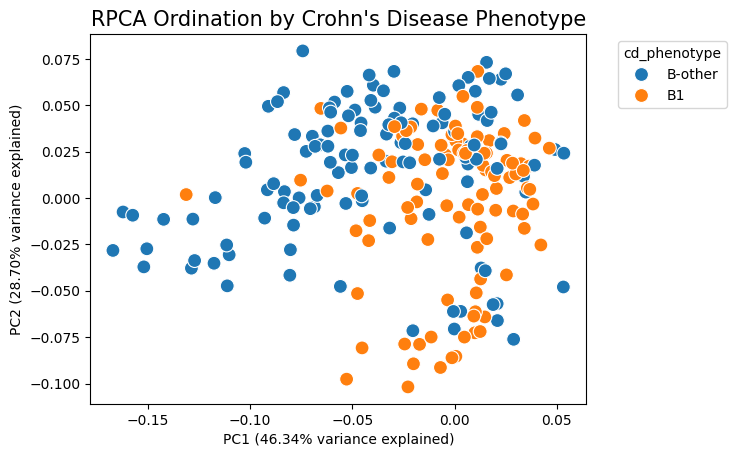

In [11]:
# Create the RPCA plot with PERMANOVA results annotation
sns.scatterplot(
    data=df,
    x='PC1', 
    y='PC2',
    hue=target_column,
    s=100,
)

plt.title('RPCA Ordination by Crohn\'s Disease Phenotype', fontsize=15)

plt.xlabel(f'PC1 ({variance_explained[0]:.2%} variance explained)')
plt.ylabel(f'PC2 ({variance_explained[1]:.2%} variance explained)')

# Adjust legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='cd_phenotype')

# Save plot
plt.savefig('../out/figs/figure6.pdf', dpi=300, bbox_inches='tight')
plt.show()